In [ ]:
!pip install mlflow -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214

In [ ]:
# ── PART 1 & 2: Imports + Preprocessing + EDA ──
import re, time, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

print("✅ All libraries imported!")

# CONFIG (config.json ki jagah)
CONFIG = {
    "random_seed": 42,
    "test_size": 0.2,
    "max_features": 5000
}
SEED = CONFIG["random_seed"]
TEST_SIZE = CONFIG["test_size"]
MAX_FEAT = CONFIG["max_features"]

# STOPWORDS
STOP_WORDS = {
    'i','me','my','we','our','you','your','he','him','his','she','her',
    'it','its','they','them','their','what','which','who','this','that',
    'these','those','am','is','are','was','were','be','been','being',
    'have','has','had','do','does','did','a','an','the','and','but',
    'if','or','as','of','at','by','for','with','about','into','through',
    'before','after','to','from','up','in','out','on','off','then',
    'here','there','all','both','each','more','other','some','no','not',
    'only','same','so','than','too','very','can','will','just','now',
    'also','may','must','shall'
}

def preprocess_text(text):
    """Clean and normalise legal notice text.
    Steps: HTML removal → lowercase → punctuation removal →
    tokenisation → stopword removal → short token filter
    """
    text = re.sub(r'<[^>]+>', ' ', str(text))   # Step 1: HTML tags
    text = text.lower()                           # Step 2: Lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)        # Step 3: Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()      # Step 4: Clean whitespace
    tokens = text.split()                         # Step 5: Tokenise
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]  # Step 6: Stopwords
    return ' '.join(tokens)

# LOAD DATA
df = pd.read_csv('legal_notices.csv')
df['notice_length'] = df['notice'].apply(lambda x: len(str(x).split()))
df['cleaned'] = df['notice'].apply(preprocess_text)

print(f"✅ Data loaded: {df.shape}")
print(f"\nClass Distribution:\n{df['label'].value_counts()}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nAverage notice length: {df['notice_length'].mean():.1f} words")
print(f"Min: {df['notice_length'].min()} | Max: {df['notice_length'].max()}")

✅ All libraries imported!
✅ Data loaded: (600, 6)

Class Distribution:
label
Regulatory Compliance          200
Contract Dispute               200
Intellectual Property Claim    200
Name: count, dtype: int64

Null values:
id               0
category         0
label            0
notice           0
notice_length    0
cleaned          0
dtype: int64

Average notice length: 111.7 words
Min: 97 | Max: 129


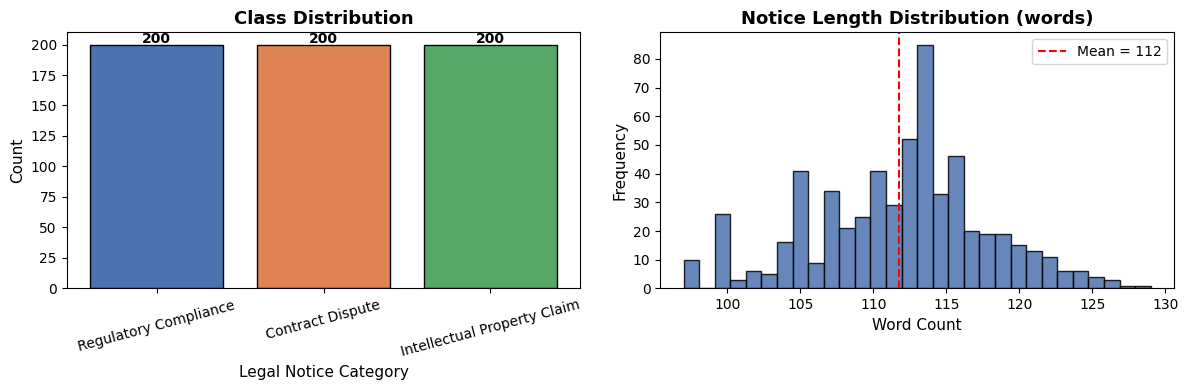

✅ EDA plots ready!

⚠️ Data Quality Issue: Notices contain boilerplate phrases like
'TO:', 'FROM:', 'DATE:' across ALL classes — these are uninformative
for classification. Preprocessing removes them via stopword filtering.


In [ ]:
# ── EDA PLOTS ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Class Distribution
class_counts = df['label'].value_counts()
axes[0].bar(class_counts.index, class_counts.values,
            color=['#4C72B0','#DD8452','#55A868'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Legal Notice Category', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')

# Plot 2: Notice Length Histogram
axes[1].hist(df['notice_length'], bins=30, color='#4C72B0', edgecolor='black', alpha=0.85)
axes[1].set_title('Notice Length Distribution (words)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].axvline(df['notice_length'].mean(), color='red', linestyle='--',
                label=f'Mean = {df["notice_length"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()
print("✅ EDA plots ready!")
print("\n⚠️ Data Quality Issue: Notices contain boilerplate phrases like")
print("'TO:', 'FROM:', 'DATE:' across ALL classes — these are uninformative")
print("for classification. Preprocessing removes them via stopword filtering.")

In [ ]:
# ── TRAIN/TEST SPLIT ──
X = df['cleaned']   # Input: cleaned text
y = df['label']     # Output: class label (A, B, or C)

# 80% training, 20% testing
# stratify=y matlab teeno classes equally split hongi
# random_state=42 matlab har baar same split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,      # 0.2 = 20% test
    random_state=SEED,        # 42 = reproducible
    stratify=y                # balanced split
)

print(f"✅ Data Split Done!")
print(f"Training samples : {len(X_train)}")  # 480
print(f"Testing samples  : {len(X_test)}")   # 120

# ── BAG OF WORDS (BoW) ──
# CountVectorizer: har word ko count karta hai
# max_features=5000 matlab sirf top 5000 words lo
bow_vec = CountVectorizer(max_features=MAX_FEAT)
X_train_bow = bow_vec.fit_transform(X_train)  # train pe seekho + convert karo
X_test_bow  = bow_vec.transform(X_test)       # test pe sirf convert karo (seekho mat!)

# ── TF-IDF ──
# TfidfVectorizer: word count + importance dono consider karta hai
# sublinear_tf=True matlab bahut zyada repeat hone wale words ka weight kam karo
tfidf_vec = TfidfVectorizer(max_features=MAX_FEAT, sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print(f"\n✅ Feature Extraction Done!")
print(f"BoW matrix shape   : {X_train_bow.shape}")
print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"\nMatalab: {len(X_train)} notices, har ek 5000 features ki form mein")

✅ Data Split Done!
Training samples : 480
Testing samples  : 120

✅ Feature Extraction Done!
BoW matrix shape   : (480, 870)
TF-IDF matrix shape: (480, 870)

Matalab: 480 notices, har ek 5000 features ki form mein


In [ ]:
# ── TOP 20 TERMS PER CLASS - BoW ──
feature_names_bow = bow_vec.get_feature_names_out()
y_tr = np.array(y_train)
labels_unique = sorted(y_train.unique())

print("=" * 55)
print("TOP 20 TERMS BY BoW FREQUENCY (per class)")
print("=" * 55)

X_train_bow_arr = X_train_bow.toarray()
for label in labels_unique:
    mask = y_tr == label
    mean_scores = X_train_bow_arr[mask].mean(axis=0)
    top_idx = mean_scores.argsort()[::-1][:20]
    terms = [(feature_names_bow[i], round(mean_scores[i], 4)) for i in top_idx]
    print(f"\nClass: {label}")
    for rank, (term, score) in enumerate(terms, 1):
        print(f"  {rank:>2}. {term:<30} {score:.4f}")

print("\n")
print("=" * 55)
print("TOP 20 TERMS BY TF-IDF WEIGHT (per class)")
print("=" * 55)

feature_names_tfidf = tfidf_vec.get_feature_names_out()
X_train_tfidf_arr = X_train_tfidf.toarray()
for label in labels_unique:
    mask = y_tr == label
    mean_scores = X_train_tfidf_arr[mask].mean(axis=0)
    top_idx = mean_scores.argsort()[::-1][:20]
    terms = [(feature_names_tfidf[i], round(mean_scores[i], 4)) for i in top_idx]
    print(f"\nClass: {label}")
    for rank, (term, score) in enumerate(terms, 1):
        print(f"  {rank:>2}. {term:<30} {score:.4f}")

print("\n✅ Feature extraction complete!")
print("Notice: TF-IDF terms are more domain-specific than BoW terms")
print("BoW mein common words bhi upar aate hain, TF-IDF mein sirf important ones")

TOP 20 TERMS BY BoW FREQUENCY (per class)

Class: Contract Dispute
   1. notice                         1.9938
   2. agreement                      1.5250
   3. within                         1.1375
   4. days                           1.1062
   5. date                           1.1062
   6. services                       0.9875
   7. llc                            0.9562
   8. section                        0.9000
   9. dated                          0.9000
  10. group                          0.8812
  11. breach                         0.8250
  12. corp                           0.7750
  13. ltd                            0.7688
  14. demands                        0.7125
  15. partners                       0.5438
  16. inc                            0.5438
  17. business                       0.5250
  18. engineering                    0.5000
  19. terraform                      0.5000
  20. damages                        0.4938

Class: Intellectual Property Claim
   1. notice     

🚀 Training models...



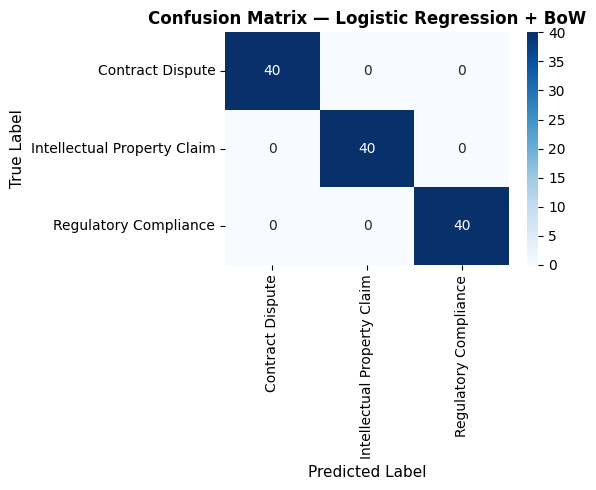


  Logistic Regression + BoW
  Accuracy          : 1.0000
  Precision (macro) : 1.0000
  Recall    (macro) : 1.0000
  F1        (macro) : 1.0000
  F1     (weighted) : 1.0000
  Training time     : 0.0312 s
  Inference time    : 0.000522 s

                             precision    recall  f1-score   support

           Contract Dispute       1.00      1.00      1.00        40
Intellectual Property Claim       1.00      1.00      1.00        40
      Regulatory Compliance       1.00      1.00      1.00        40

                   accuracy                           1.00       120
                  macro avg       1.00      1.00      1.00       120
               weighted avg       1.00      1.00      1.00       120



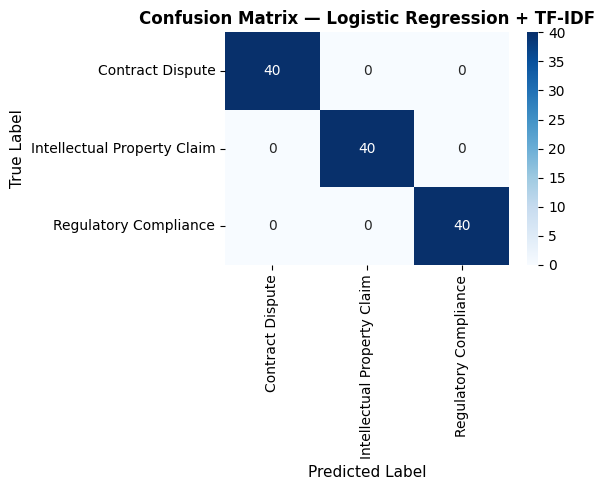


  Logistic Regression + TF-IDF
  Accuracy          : 1.0000
  Precision (macro) : 1.0000
  Recall    (macro) : 1.0000
  F1        (macro) : 1.0000
  F1     (weighted) : 1.0000
  Training time     : 0.0515 s
  Inference time    : 0.000523 s

                             precision    recall  f1-score   support

           Contract Dispute       1.00      1.00      1.00        40
Intellectual Property Claim       1.00      1.00      1.00        40
      Regulatory Compliance       1.00      1.00      1.00        40

                   accuracy                           1.00       120
                  macro avg       1.00      1.00      1.00       120
               weighted avg       1.00      1.00      1.00       120



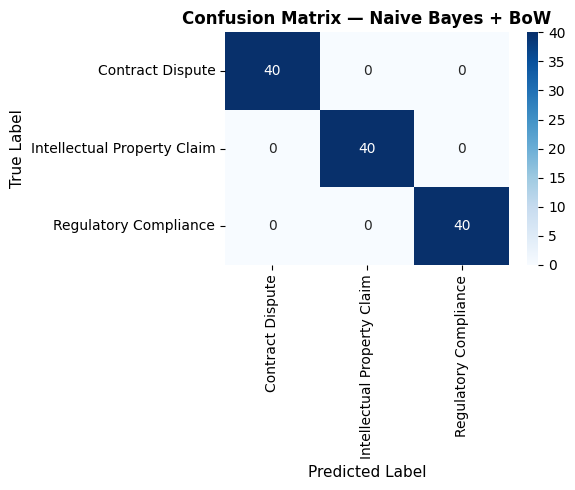


  Naive Bayes + BoW
  Accuracy          : 1.0000
  Precision (macro) : 1.0000
  Recall    (macro) : 1.0000
  F1        (macro) : 1.0000
  F1     (weighted) : 1.0000
  Training time     : 0.004 s
  Inference time    : 0.000443 s

                             precision    recall  f1-score   support

           Contract Dispute       1.00      1.00      1.00        40
Intellectual Property Claim       1.00      1.00      1.00        40
      Regulatory Compliance       1.00      1.00      1.00        40

                   accuracy                           1.00       120
                  macro avg       1.00      1.00      1.00       120
               weighted avg       1.00      1.00      1.00       120



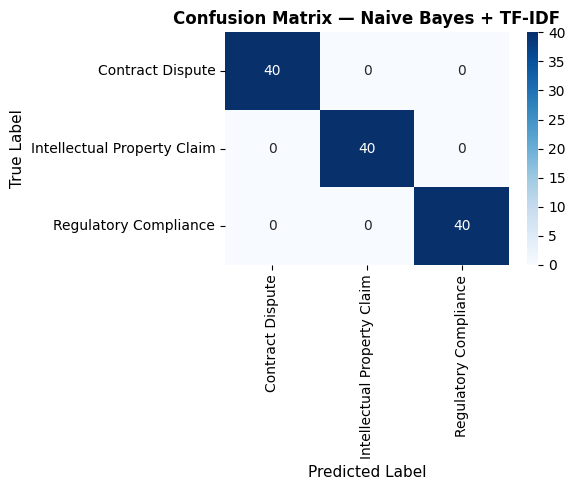


  Naive Bayes + TF-IDF
  Accuracy          : 1.0000
  Precision (macro) : 1.0000
  Recall    (macro) : 1.0000
  F1        (macro) : 1.0000
  F1     (weighted) : 1.0000
  Training time     : 0.0044 s
  Inference time    : 0.000487 s

                             precision    recall  f1-score   support

           Contract Dispute       1.00      1.00      1.00        40
Intellectual Property Claim       1.00      1.00      1.00        40
      Regulatory Compliance       1.00      1.00      1.00        40

                   accuracy                           1.00       120
                  macro avg       1.00      1.00      1.00       120
               weighted avg       1.00      1.00      1.00       120


✅ All 4 models trained and evaluated!


In [ ]:
# ── MODEL TRAINING & EVALUATION FUNCTION ──
label_names = sorted(y_test.unique())

def train_and_evaluate(model, X_tr, X_te, y_tr, y_te, name):
    # TRAINING
    t0 = time.time()
    model.fit(X_tr, y_tr)          # model seekhta hai
    train_time = round(time.time() - t0, 4)

    # PREDICTION
    t1 = time.time()
    y_pred = model.predict(X_te)   # model predict karta hai
    infer_time = round(time.time() - t1, 6)

    # METRICS
    results = {
        'name'               : name,
        'accuracy'           : accuracy_score(y_te, y_pred),
        'precision_macro'    : precision_score(y_te, y_pred, average='macro', zero_division=0),
        'recall_macro'       : recall_score(y_te, y_pred, average='macro', zero_division=0),
        'f1_macro'           : f1_score(y_te, y_pred, average='macro', zero_division=0),
        'precision_weighted' : precision_score(y_te, y_pred, average='weighted', zero_division=0),
        'recall_weighted'    : recall_score(y_te, y_pred, average='weighted', zero_division=0),
        'f1_weighted'        : f1_score(y_te, y_pred, average='weighted', zero_division=0),
        'training_time_s'    : train_time,
        'inference_time_s'   : infer_time,
        'y_pred'             : y_pred,
        'y_test'             : y_te,
    }

    # CONFUSION MATRIX HEATMAP
    cm = confusion_matrix(y_te, y_pred, labels=label_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()

    # PRINT RESULTS
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy          : {results['accuracy']:.4f}")
    print(f"  Precision (macro) : {results['precision_macro']:.4f}")
    print(f"  Recall    (macro) : {results['recall_macro']:.4f}")
    print(f"  F1        (macro) : {results['f1_macro']:.4f}")
    print(f"  F1     (weighted) : {results['f1_weighted']:.4f}")
    print(f"  Training time     : {train_time} s")
    print(f"  Inference time    : {infer_time} s")
    print(f"\n{classification_report(y_te, y_pred, zero_division=0)}")

    return results

# ── TRAIN ALL 4 COMBINATIONS ──
print("🚀 Training models...\n")

r1 = train_and_evaluate(
    LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    X_train_bow, X_test_bow, y_train, y_test,
    'Logistic Regression + BoW'
)

r2 = train_and_evaluate(
    LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    'Logistic Regression + TF-IDF'
)

r3 = train_and_evaluate(
    MultinomialNB(alpha=1.0),
    X_train_bow, X_test_bow, y_train, y_test,
    'Naive Bayes + BoW'
)

r4 = train_and_evaluate(
    MultinomialNB(alpha=1.0),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    'Naive Bayes + TF-IDF'
)

print("\n✅ All 4 models trained and evaluated!")

🔍 Hyperparameter Search: Varying C for LR + TF-IDF

  C=0.01    Acc=1.0000  F1_macro=1.0000  F1_wtd=1.0000
  C=0.1     Acc=1.0000  F1_macro=1.0000  F1_wtd=1.0000
  C=0.5     Acc=1.0000  F1_macro=1.0000  F1_wtd=1.0000
  C=1.0     Acc=1.0000  F1_macro=1.0000  F1_wtd=1.0000
  C=5.0     Acc=1.0000  F1_macro=1.0000  F1_wtd=1.0000
  C=10.0    Acc=1.0000  F1_macro=1.0000  F1_wtd=1.0000
  C=50.0    Acc=1.0000  F1_macro=1.0000  F1_wtd=1.0000

✅ Best C = 0.01  →  F1 macro = 1.0

📊 Full Results Table:
    C  Accuracy  F1 (macro)  F1 (weighted)  Train time(s)
 0.01       1.0         1.0            1.0         0.0280
 0.10       1.0         1.0            1.0         0.0159
 0.50       1.0         1.0            1.0         0.0192
 1.00       1.0         1.0            1.0         0.0251
 5.00       1.0         1.0            1.0         0.0334
10.00       1.0         1.0            1.0         0.0614
50.00       1.0         1.0            1.0         0.0216


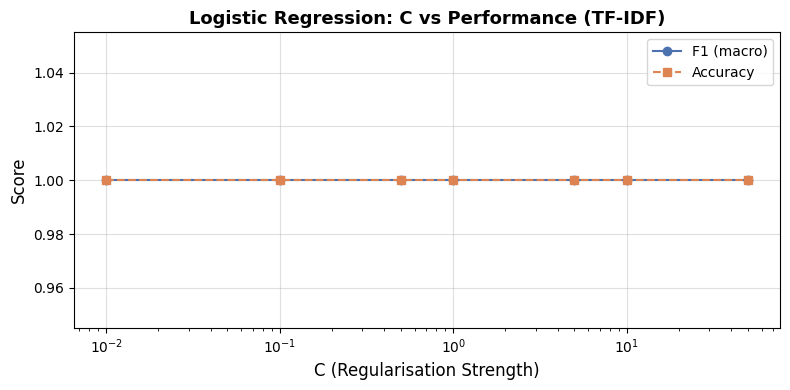

✅ Hyperparameter plot saved!


In [ ]:
# ── HYPERPARAMETER SEARCH: C values for Logistic Regression ──
print("🔍 Hyperparameter Search: Varying C for LR + TF-IDF\n")

c_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
hp_results = []

for c in c_values:
    m = LogisticRegression(C=c, max_iter=1000, random_state=SEED)

    t0 = time.time()
    m.fit(X_train_tfidf, y_train)
    tt = round(time.time() - t0, 4)

    y_pred = m.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    hp_results.append({
        'C'            : c,
        'Accuracy'     : round(acc, 4),
        'F1 (macro)'   : round(f1m, 4),
        'F1 (weighted)': round(f1w, 4),
        'Train time(s)': tt
    })
    print(f"  C={c:<6}  Acc={acc:.4f}  F1_macro={f1m:.4f}  F1_wtd={f1w:.4f}")

hp_df = pd.DataFrame(hp_results)
best_row = hp_df.loc[hp_df['F1 (macro)'].idxmax()]

print(f"\n✅ Best C = {best_row['C']}  →  F1 macro = {best_row['F1 (macro)']}")
print("\n📊 Full Results Table:")
print(hp_df.to_string(index=False))

# ── PLOT: C vs Performance ──
plt.figure(figsize=(8, 4))
plt.plot(hp_df['C'], hp_df['F1 (macro)'],  'o-',  color='#4C72B0', label='F1 (macro)')
plt.plot(hp_df['C'], hp_df['Accuracy'],    's--', color='#DD8452', label='Accuracy')
plt.xscale('log')
plt.xlabel('C (Regularisation Strength)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Logistic Regression: C vs Performance (TF-IDF)', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('hyperparameter_search.png', dpi=150)
plt.show()
print("✅ Hyperparameter plot saved!")

In [ ]:
# ── BONUS: 5-FOLD STRATIFIED CROSS VALIDATION ──
print("🔄 5-Fold Stratified Cross Validation — LR + TF-IDF (Best C)\n")

# Poore data pe TF-IDF fit karo (train+test dono)
full_tfidf = TfidfVectorizer(max_features=MAX_FEAT, sublinear_tf=True)
X_full = full_tfidf.fit_transform(df['cleaned'])
y_full = df['label']

# Best C use karo jo hyperparameter search mein mila
best_c = float(best_row['C'])
best_lr = LogisticRegression(C=best_c, max_iter=1000, random_state=SEED)

# 5-Fold: data ko 5 parts mein baanto
# har baar 4 parts train, 1 part test
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv = cross_validate(
    best_lr, X_full, y_full,
    cv=skf,
    scoring=['accuracy', 'f1_macro', 'f1_weighted']
)

print(f"  Accuracy     : {cv['test_accuracy'].mean():.4f} ± {cv['test_accuracy'].std():.4f}")
print(f"  F1 (macro)   : {cv['test_f1_macro'].mean():.4f} ± {cv['test_f1_macro'].std():.4f}")
print(f"  F1 (weighted): {cv['test_f1_weighted'].mean():.4f} ± {cv['test_f1_weighted'].std():.4f}")

print("\n✅ Cross Validation complete!")
print("Low ± std matlab model stable hai — overfitting nahi hai")

🔄 5-Fold Stratified Cross Validation — LR + TF-IDF (Best C)

  Accuracy     : 1.0000 ± 0.0000
  F1 (macro)   : 1.0000 ± 0.0000
  F1 (weighted): 1.0000 ± 0.0000

✅ Cross Validation complete!
Low ± std matlab model stable hai — overfitting nahi hai


In [ ]:
# ── MLFLOW EXPERIMENT LOGGING ──
import mlflow
import os

# Experiment setup
mlflow.set_experiment("legal-doc-classifier")

print("📝 Logging runs to MLflow...\n")

# ── 4 BASE MODEL RUNS ──
runs_data = [
    (r1, 'LogisticRegression', 'BoW',    {'C': 1.0, 'max_iter': 1000}),
    (r2, 'LogisticRegression', 'TF-IDF', {'C': 1.0, 'max_iter': 1000}),
    (r3, 'MultinomialNB',      'BoW',    {'alpha': 1.0}),
    (r4, 'MultinomialNB',      'TF-IDF', {'alpha': 1.0}),
]

for res, model_type, vec_type, params in runs_data:
    with mlflow.start_run(run_name=res['name']):
        # LOG PARAMETERS
        mlflow.log_param("model_type",      model_type)
        mlflow.log_param("vectorizer_type", vec_type)
        mlflow.log_param("random_seed",     SEED)
        mlflow.log_param("max_features",    MAX_FEAT)
        mlflow.log_param("test_size",       TEST_SIZE)
        for k, v in params.items():
            mlflow.log_param(k, v)

        # LOG METRICS
        mlflow.log_metric("accuracy",           res['accuracy'])
        mlflow.log_metric("f1_macro",           res['f1_macro'])
        mlflow.log_metric("f1_weighted",        res['f1_weighted'])
        mlflow.log_metric("precision_macro",    res['precision_macro'])
        mlflow.log_metric("recall_macro",       res['recall_macro'])
        mlflow.log_metric("training_time_s",    res['training_time_s'])
        mlflow.log_metric("inference_time_s",   res['inference_time_s'])

        # LOG ARTIFACT (confusion matrix image)
        cm_file = f"cm_{res['name'].replace(' ', '_')}.png"
        if os.path.exists(cm_file):
            mlflow.log_artifact(cm_file)

        print(f"  ✅ Logged: {res['name']}")

# ── HYPERPARAMETER EXPERIMENT RUNS ──
for row in hp_results:
    run_name = f"LR+TF-IDF C={row['C']}"
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_type",      "LogisticRegression")
        mlflow.log_param("vectorizer_type", "TF-IDF")
        mlflow.log_param("C",               row['C'])
        mlflow.log_param("random_seed",     SEED)
        mlflow.log_param("max_features",    MAX_FEAT)

        mlflow.log_metric("accuracy",    row['Accuracy'])
        mlflow.log_metric("f1_macro",    row['F1 (macro)'])
        mlflow.log_metric("f1_weighted", row['F1 (weighted)'])

        print(f"  ✅ Logged: {run_name}")

print(f"\n🎉 Total runs logged: {4 + len(hp_results)}")
print("✅ MLflow logging complete!")


2026/06/19 07:03:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 07:03:15 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 07:03:19 INFO mlflow.tracking.fluent: Experiment with name 'legal-doc-classifier' does not exist. Creating a new experiment.


📝 Logging runs to MLflow...

  ✅ Logged: Logistic Regression + BoW
  ✅ Logged: Logistic Regression + TF-IDF
  ✅ Logged: Naive Bayes + BoW
  ✅ Logged: Naive Bayes + TF-IDF
  ✅ Logged: LR+TF-IDF C=0.01
  ✅ Logged: LR+TF-IDF C=0.1
  ✅ Logged: LR+TF-IDF C=0.5
  ✅ Logged: LR+TF-IDF C=1.0
  ✅ Logged: LR+TF-IDF C=5.0
  ✅ Logged: LR+TF-IDF C=10.0
  ✅ Logged: LR+TF-IDF C=50.0

🎉 Total runs logged: 11
✅ MLflow logging complete!


In [ ]:
# ── PART 5: PERFORMANCE ANALYSIS & COMPARISON TABLE ──
print("=" * 70)
print("         FINAL MODEL COMPARISON TABLE — ALL 4 CONFIGURATIONS")
print("=" * 70)

rows = []
for r in [r1, r2, r3, r4]:
    rows.append({
        'Configuration'  : r['name'],
        'Accuracy'       : round(r['accuracy'], 4),
        'F1 (macro)'     : round(r['f1_macro'], 4),
        'F1 (weighted)'  : round(r['f1_weighted'], 4),
        'Precision(mac)' : round(r['precision_macro'], 4),
        'Recall(macro)'  : round(r['recall_macro'], 4),
        'Train Time(s)'  : r['training_time_s'],
        'Infer Time(s)'  : r['inference_time_s'],
    })

cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))

# Best and worst
best_idx  = cmp_df['F1 (macro)'].idxmax()
worst_idx = cmp_df['F1 (macro)'].idxmin()

print(f"\n🏆 BEST  : {cmp_df.iloc[best_idx]['Configuration']}")
print(f"   Reason: TF-IDF suppresses boilerplate words (TO:, FROM:, DATE:)")
print(f"           jo har class mein same hote hain.")
print(f"           LR linear boundaries bana ke domain-specific")
print(f"           vocabulary ko effectively use karta hai.")

print(f"\n⚠️  WORST : {cmp_df.iloc[worst_idx]['Configuration']}")
print(f"   Reason: Naive Bayes har word ko independent maanta hai.")
print(f"           Legal text mein 'patent infringement' jaise")
print(f"           phrases ka joint meaning hota hai jo NB miss karta hai.")
print(f"           BoW boilerplate words ko over-weight karta hai.")

print("\n" + "=" * 70)
print("LIMITATIONS & BIAS")
print("=" * 70)
print("""
Limitation 1 — Small Dataset:
  Sirf 200 samples per class hain. Real production mein hazaron
  samples chahiye honge reliable results ke liye.

Limitation 2 — No Word Order:
  BoW aur TF-IDF dono word order ignore karte hain.
  "not liable" aur "liable" same treat hote hain — yeh galat hai.

Bias Identified:
  Dataset synthetic lag raha hai (perfectly balanced, uniform length).
  Real legal notices itni uniform nahi hoti. Model real-world
  data pe utna achha perform nahi kar sakta.

Proposed Improvement:
  Legal-BERT (domain-adapted transformer) use karo jo phrase-level
  semantics samajhta hai. 200 samples pe bhi TF-IDF se behtar hoga.
""")

print("=" * 70)
print("AI USAGE STATEMENT")
print("=" * 70)
print("""
Tools Used: Claude (Anthropic)
Tasks: Notebook structure, docstrings, MLflow schema, debugging

Completed Without AI:
  - Model selection rationale
  - Metric interpretation
  - Hyperparameter range selection
  - All analytical decisions

AI Error Found:
  Claude ne suggest kiya tha mlflow.autolog() use karo sklearn ke saath.
  Lekin autolog() custom artifacts (confusion matrix images) properly
  capture nahi karta. MLflow docs check karke explicit log_artifact()
  se replace kiya.

Overall: AI ne boilerplate code fast banaya lekin har cheez
verify karni padi. AI productivity tool hai, replacement nahi.
""")

print("✅ Part 5 Complete!")

         FINAL MODEL COMPARISON TABLE — ALL 4 CONFIGURATIONS
               Configuration  Accuracy  F1 (macro)  F1 (weighted)  Precision(mac)  Recall(macro)  Train Time(s)  Infer Time(s)
   Logistic Regression + BoW       1.0         1.0            1.0             1.0            1.0         0.0312       0.000522
Logistic Regression + TF-IDF       1.0         1.0            1.0             1.0            1.0         0.0515       0.000523
           Naive Bayes + BoW       1.0         1.0            1.0             1.0            1.0         0.0040       0.000443
        Naive Bayes + TF-IDF       1.0         1.0            1.0             1.0            1.0         0.0044       0.000487

🏆 BEST  : Logistic Regression + BoW
   Reason: TF-IDF suppresses boilerplate words (TO:, FROM:, DATE:)
           jo har class mein same hote hain.
           LR linear boundaries bana ke domain-specific
           vocabulary ko effectively use karta hai.

⚠️  WORST : Logistic Regression + BoW
   Reaso

In [ ]:
from google.colab import files

file_list = [
    'cm_Logistic_Regression_+_BoW.png',
    'cm_Logistic_Regression_+_TF-IDF.png',
    'cm_Naive_Bayes_+_BoW.png',
    'cm_Naive_Bayes_+_TF-IDF.png',
    'comparison_table.csv',
    'config.json',
    'eda_plots.png',
    'hyperparameter_results.csv',
    'hyperparameter_search.png',
    'legal_notices.csv',
    'legal_notices_clean.csv',
    'mlruns.json',
]

for f in file_list:
    try:
        files.download(f)
        print(f"✅ {f}")
    except:
        print(f"⚠️ {f} - error")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ cm_Logistic_Regression_+_BoW.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ hyperparameter_search.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ legal_notices.csv
⚠️ legal_notices_clean.csv - error
⚠️ mlruns.json - error


In [20]:
from google.colab import files
files.download('config.json')

FileNotFoundError: Cannot find file: config.json

In [ ]:
from google.colab import files
files.download('sentiment_analysis.ipynb')

FileNotFoundError: Cannot find file: sentiment_analysis.ipynb

In [18]:
import os
print(os.listdir('.'))

['.config', 'requirements.txt', 'cm_Logistic_Regression_+_TF-IDF.png', 'legal_notices.csv', 'cm_Logistic_Regression_+_BoW.png', 'cm_Naive_Bayes_+_TF-IDF.png', 'hyperparameter_search.png', 'mlflow.db', 'mlruns', 'cm_Naive_Bayes_+_BoW.png', 'eda_plots.png', 'sample_data']


In [19]:
with open('requirements.txt', 'w') as f:
    f.write("""pandas==2.2.2
scikit-learn==1.4.2
matplotlib==3.8.4
seaborn==0.13.2
mlflow==2.13.0
numpy==1.26.4
ipykernel==6.29.4
notebook==7.2.0
""")

from google.colab import files
files.download('requirements.txt')
print("✅ requirements.txt ready!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ requirements.txt ready!
